In [70]:
import glob, os, warnings
import palettable
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import math
import vcf
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# mapping of mutation type to color. Only these mutation types are shown. Can be any valid matplotlib color, e.g. 'blue', #ffa500, or (1,1,1).
balance_6 = palettable.cmocean.diverging.Balance_6.mpl_colors
safe_10 = palettable.cartocolors.qualitative.Safe_10.mpl_colors
vivid_10 = palettable.cartocolors.qualitative.Vivid_10.mpl_colors
purp_7 = palettable.cartocolors.sequential.Purp_7.mpl_colormap
blue_seq = palettable.scientific.sequential.Devon_18.mpl_colors
gray_seq = palettable.scientific.sequential.GrayC_20.mpl_colors

warnings.filterwarnings("ignore")

# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/ARIAL*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'


CONSEQUENCE_ORDER = [ "stop_gained", "stop_lost", "start_lost", "frameshift_variant", "splice_donor_variant", "splice_acceptor_variant", "missense_variant" ]

In [71]:
class acc:
    def __init__ ( self):
        self.df = pd.DataFrame ( columns = [ sample for sample in samplenames if "Blood" not in sample ] )

    def add ( self, line, record ) :
        self.df.loc [ len ( self.df ) ] = line
        CHR, POS, REF, ALT = record.CHROM, int(record.POS), record.REF, record.ALT [0]
        self.df.index = list(self.df.index[:-1]) + [CHR + ":" + str(POS)]


#############################

def SPLICEAI ( VEP_dict ):
    import numpy as np
    import math
    filtered_list = [ float(value) for value in [VEP_dict["SpliceAI_pred_DS_AG"], VEP_dict["SpliceAI_pred_DS_AL"],  VEP_dict["SpliceAI_pred_DS_DG"], VEP_dict["SpliceAI_pred_DS_DL"]] if value != '' and value != None]
    if len ( filtered_list ) != 0:
        SpliceAI_score = np.max ( np.array ( filtered_list ) )
    else:
        SpliceAI_score = math.nan
    return SpliceAI_score

In [72]:
global samplenames 

VCF_PATH = "/data/project/Meningioma/04.mutect/02.PASS/250206_multiple.MT2.FMC.HF.RMBLACK.vep.vcf"

vcf_reader = vcf.Reader(open(VCF_PATH, "r"))
samplenames = vcf_reader.samples
samplenames_dict = { i : samplenames [i] for i in range ( len (samplenames ))  }        # {0: '250310_Tumor'}
samplenames_dict_rev = { samplenames [i] : i for i in range ( len (samplenames ))  } # { '250310_Tumor' : 0}
CSQ_TITLE = vcf_reader.infos["CSQ"].desc.split ("Format: ")[1].split ("|")

vaf_acc = acc  ( ) 
dp_acc = acc  ( ) 
alt_acc = acc  ( ) 
CSQ_acc = acc  ( ); CSQ_acc.df = pd.DataFrame ( columns = CSQ_TITLE )

for record in vcf_reader:
    CHR, POS, REF, ALT = record.CHROM, int(record.POS), record.REF, record.ALT [0]

    if (record.num_het == len(samplenames) - 1) :
        check = -1
        for k in range ( len ( record.INFO["CSQ"] ) ):
            CSQ_dict = {}; CSQ_line = []
            for i, title in enumerate ( CSQ_TITLE ) :
                CSQ_dict [ title ] = record.INFO["CSQ"][k].split ("|")[i]

            if any(i in CSQ_dict["Consequence"] for i in CONSEQUENCE_ORDER):
                for i, title in enumerate ( CSQ_TITLE ) :
                    CSQ_line.append ( CSQ_dict [ title ] )
                CSQ_acc.add ( CSQ_line, record )
                check = k
                break
        
        if check == -1:
            CSQ_dict = {}; CSQ_line = []
            for i, title in enumerate ( CSQ_TITLE ) :
                CSQ_dict [ title ] = record.INFO["CSQ"][0].split ("|")[i]
                CSQ_line.append ( CSQ_dict [ title ] )
            CSQ_acc.add ( CSQ_line, record )
        

        vaf_line, dp_line, alt_line = [], [], []
        for sample_i, sample in enumerate ( samplenames ) :
            if "Blood" in sample :
                continue
            vaf_line.append (  record.samples [ sample_i ].data.AF[0]  )
            dp_line.append (  record.samples [ sample_i ].data.DP  )
            alt_line.append (  record.samples [ sample_i ].data.AD[1]  )
            
        vaf_acc.add ( vaf_line, record  )
        dp_acc.add ( dp_line, record )
        alt_acc.add ( alt_line, record )


    # record.INFO  (#dict)
    # record.INFO["DP"]
    # record.INFO["CSQ"]

In [73]:
CSQ_acc.df

,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,DISTANCE,STRAND,FLAGS,VARIANT_CLASS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,SOURCE,GENE_PHENO,SIFT,PolyPhen,DOMAINS,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,AA_AF,EA_AF,gnomAD_AF,gnomAD_AFR_AF,gnomAD_AMR_AF,gnomAD_ASJ_AF,gnomAD_EAS_AF,gnomAD_FIN_AF,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,MAX_AF,MAX_AF_POPS,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALSPAC_AC,ALSPAC_AF,APPRIS,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AltaiNeandertal,Ancestral_allele,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,CADD_phred,CADD_phred_hg19,CADD_raw,CADD_raw_hg19,CADD_raw_rankscore,CADD_raw_rankscore_hg19,ClinPred_pred,ClinPred_rankscore,ClinPred_score,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESP6500_AA_AC,ESP6500_AA_AF,ESP6500_EA_AC,ESP6500_EA_AF,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,ExAC_AC,ExAC_AF,ExAC_AFR_AC,ExAC_AFR_AF,ExAC_AMR_AC,ExAC_AMR_AF,ExAC_Adj_AC,ExAC_Adj_AF,ExAC_EAS_AC,ExAC_EAS_AF,ExAC_FIN_AC,ExAC_FIN_AF,ExAC_NFE_AC,ExAC_NFE_AF,ExAC_SAS_AC,ExAC_SAS_AF,ExAC_nonTCGA_AC,ExAC_nonTCGA_AF,ExAC_nonTCGA_AFR_AC,ExAC_nonTCGA_AFR_AF,ExAC_nonTCGA_AMR_AC,ExAC_nonTCGA_AMR_AF,ExAC_nonTCGA_Adj_AC,ExAC_nonTCGA_Adj_AF,ExAC_nonTCGA_EAS_AC,ExAC_nonTCGA_EAS_AF,ExAC_nonTCGA_FIN_AC,ExAC_nonTCGA_FIN_AF,ExAC_nonTCGA_NFE_AC,ExAC_nonTCGA_NFE_AF,ExAC_nonTCGA_SAS_AC,ExAC_nonTCGA_SAS_AF,ExAC_nonpsych_AC,ExAC_nonpsych_AF,ExAC_nonpsych_AFR_AC,ExAC_nonpsych_AFR_AF,ExAC_nonpsych_AMR_AC,ExAC_nonpsych_AMR_AF,ExAC_nonpsych_Adj_AC,ExAC_nonpsych_Adj_AF,ExAC_nonpsych_EAS_AC,ExAC_nonpsych_EAS_AF,ExAC_nonpsych_FIN_AC,ExAC_nonpsych_FIN_AF,ExAC_nonpsych_NFE_AC,ExAC_nonpsych_NFE_AF,ExAC_nonpsych_SAS_AC,ExAC_nonpsych_SAS_AF,FATHMM_converted_rankscore,FATHMM_pred,FATHMM_score,GENCODE_basic,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GM12878_confidence_value,GM12878_fitCons_rankscore,GM12878_fitCons_score,GTEx_V8_gene,GTEx_V8_tissue,GenoCanyon_rankscore,GenoCanyon_score,Geuvadis_eQTL_target_gene,H1-hESC_confidence_value,H1-hESC_fitCons_rankscore,H1-hESC_fitCons_score,HGVSc_ANNOVAR,HGVSc_VEP,HGVSc_snpEff,HGVSp_ANNOVAR,HGVSp_VEP,HGVSp_snpEff,HUVEC_confidence_value,HUVEC_fitCons_rankscore,HUVEC_fitCons_score,Interpro_domain,LINSIGHT,LINSIGHT_rankscore,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,LRT_Omega,LRT_converted_rankscore,LRT_pred,LRT_score,M-CAP_pred,M-CAP_rankscore,M-CAP_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutPred_AAchange,MutPred_Top5features,MutPred_protID,MutPred_rankscore,MutPred_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_AAE,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,MutationTaster_score,PROVEAN_converted_rankscore,PROVEAN_pred,PROVEAN_score,Polyphen2_HDIV_pred,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_score,Polyphen2_HVAR_pred,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_score,PrimateAI_pred,PrimateAI_rankscore,PrimateAI_score,REVEL_rankscore,REVEL_scor

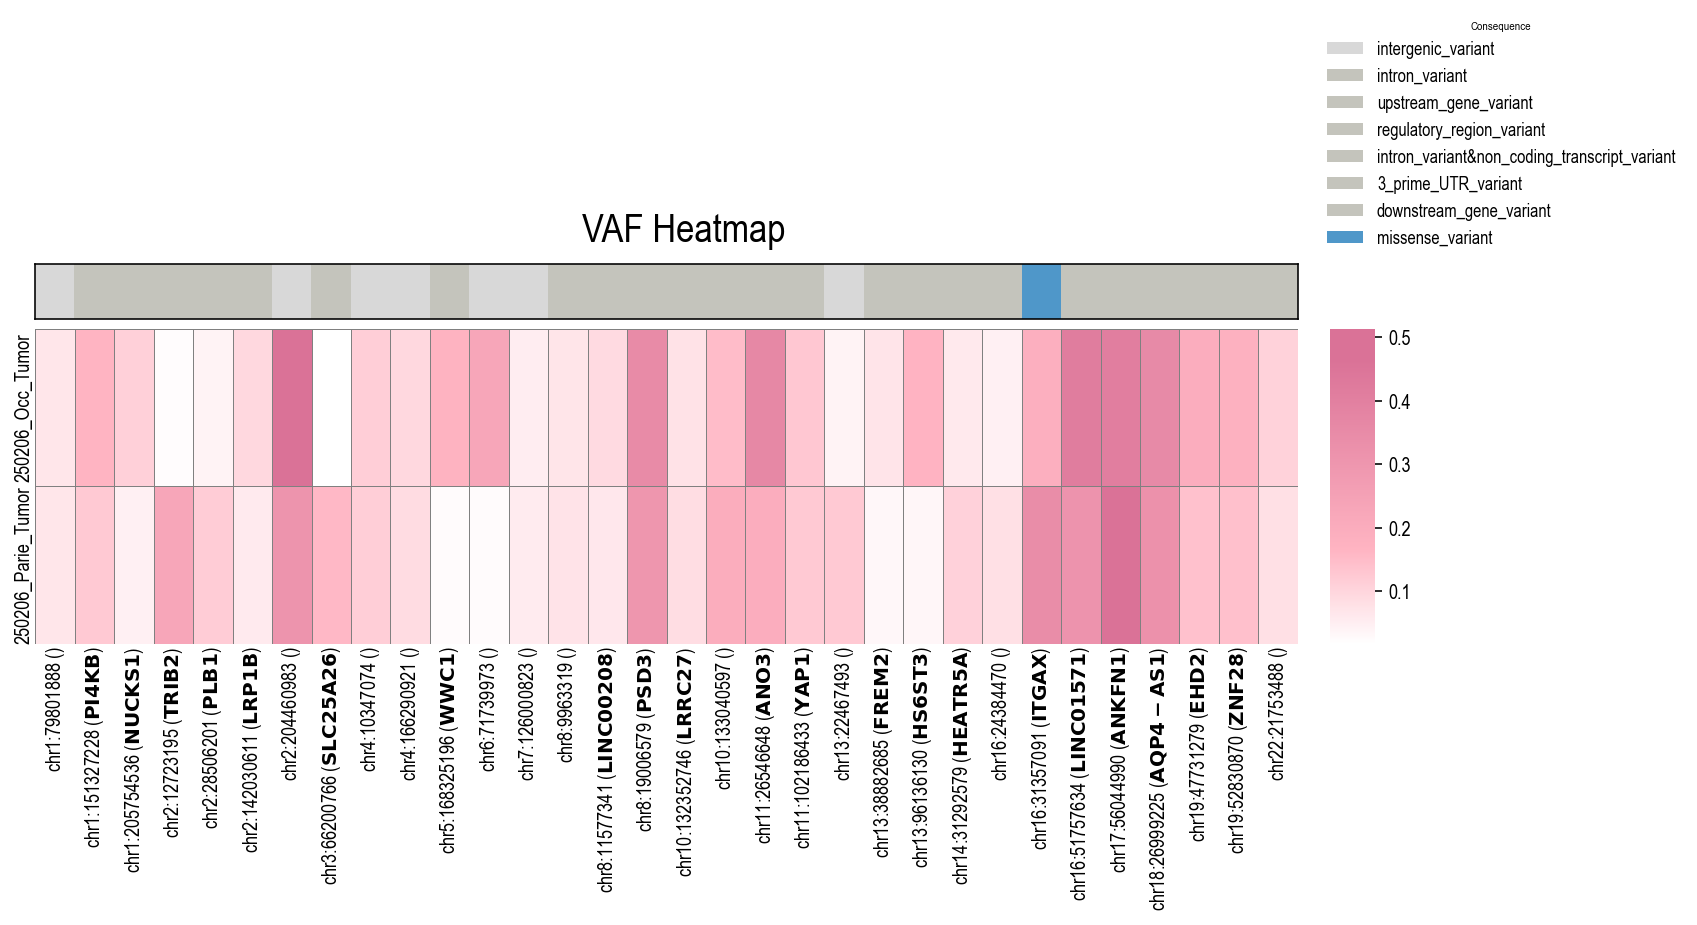

In [120]:
def VISUALIZE_VAF_HEATMAP ( df_inside, kwargs ):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors
    from matplotlib import gridspec

    positions = [0, 0.3, 0.9, 1]  # 비율대로 segment를 주고 싶을 때 (position은 반드시 0~1이여야 한다)
    cmap_t = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, [ "white", "#FFB4C2", "#DA7297", "#DA7297" ] )) )

    # vaf_acc.df의 역행렬
    df_merge = pd. merge ( df_inside, CSQ_acc.df, left_index = True, right_index = True )
    df_inside = df_inside.transpose()
    
    

    fig = plt.figure(figsize=kwargs["figsize"])
    gs = gridspec.GridSpec( 2, 2,  height_ratios=[0.15, 0.85],  width_ratios=[1, 0.035],  hspace=0.05, wspace=0.05)

    ax_bar = fig.add_subplot ( gs[0, 0] )   # annotation bar
    ax     = fig.add_subplot ( gs[1, 0] )   # heatmap
    cax    = fig.add_subplot ( gs[1, 1] )   # colorbar 전용 축



    # Top: Consequence annotation bar
    global consequence_color_dict, consequence_colors
    unique_consequences = df_merge["Consequence"].unique()
    # consequence_palette = sns.color_palette("Set2", len(unique_consequences))
    # consequence_color_dict = dict(zip(unique_consequences, consequence_palette))
    consequence_color_dict  = { "stop_gained" : "#222E73", "stop_lost" : "#222E73", "start_lost" : "#222E73", "frameshift_variant" : "#8840DE", "splice_donor_variant" : "#E3471F", "splice_acceptor_variant" : "#E3471F", "missense_variant" : "#4F97C9", "intergenic_variant" : "#D8D8D8" }
    for c in unique_consequences:
        if c not in consequence_color_dict:
            consequence_color_dict[c] = "#C4C4BC"
    consequence_colors = df_merge["Consequence"].map(consequence_color_dict)
    consequence_colors_rgb = [mcolors.to_rgb(color) for color in consequence_colors]      # Convert hex color codes to RGB tuples in [0,1] for imshow
    consequence_colors_array = np.array(consequence_colors_rgb)[np.newaxis, :, :]

    ax_bar.imshow(consequence_colors_array, aspect="auto")
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    ax_bar.tick_params(axis='both', labelsize=0, pad=kwargs["tick_pad"], length=0 )

    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=consequence_color_dict[c], label=c) for c in unique_consequences]
    ax_bar.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="lower left", fontsize=9, title="Consequence", title_fontsize=6, frameon=False)

    # Bottom: VAF heatmap
    sns.heatmap ( df_inside, cmap=cmap_t,  annot=False,   linewidth=kwargs["heatmap_linewidth"],     linecolor=kwargs["heatmap_linecolor"],   ax=ax,     cbar=True, cbar_ax=cax  )
    fig.suptitle(kwargs["title"], fontsize=kwargs["title_fontsize"])
    ax.set_xlabel(kwargs["xlabel"], fontsize=kwargs["label_fontsize"], fontweight="normal", labelpad=0)
    ax.set_ylabel(kwargs["ylabel"], fontsize=kwargs["label_fontsize"], fontweight="normal", labelpad=0)
    ax.set_xticklabels ( [ df_merge.index[i] + " (" + r"$\bf{" + str(df_merge['SYMBOL'].iloc[i]) + "}$" + ")" for i in range ( len ( df_inside.columns ) ) ] )
    ax.tick_params(axis='both', labelsize=kwargs["tick_labelsize"], pad=kwargs["tick_pad"], length=kwargs["tick_length"], width=kwargs["tick_width"])

    fig.savefig(kwargs["OUTPUT_PATH"], dpi=300, bbox_inches="tight")


##################################################################################################
kwargs = {}
kwargs.update({"figsize": (12, 3.5), "title" : "VAF Heatmap",  "title_fontsize" : 20,
                        "heatmap_linewidth" : 0.5, "heatmap_linecolor" : "gray",
                        "tick_labelsize": 10, "tick_pad": 1, "tick_length": 0, "tick_width": 0.5,
                         "xlabel" : "", "ylabel" : "", "label_fontsize": 6, "OUTPUT_PATH": "/data/project/Meningioma/04.mutect/09.multiple/250206/Heatmap_VAF.jpg"})
VISUALIZE_VAF_HEATMAP ( vaf_acc.df, kwargs )


In [104]:
consequence_color_dict 

{'intergenic_variant': (0.4, 0.7607843137254902, 0.6470588235294118),
 'intron_variant': (0.9882352941176471,
  0.5529411764705883,
  0.3843137254901961),
 'upstream_gene_variant': (0.5529411764705883,
  0.6274509803921569,
  0.796078431372549),
 'regulatory_region_variant': (0.9058823529411765,
  0.5411764705882353,
  0.7647058823529411),
 'intron_variant&non_coding_transcript_variant': (0.6509803921568628,
  0.8470588235294118,
  0.32941176470588235),
 '3_prime_UTR_variant': (1.0, 0.8509803921568627, 0.1843137254901961),
 'downstream_gene_variant': (0.8980392156862745,
  0.7686274509803922,
  0.5803921568627451),
 'missense_variant': (0.7019607843137254,
  0.7019607843137254,
  0.7019607843137254)}

In [ ]:
df = pd. merge ( vaf_acc.df, CSQ_acc.df, left_index = True, right_index = True )

,250206_Occ_Tumor,250206_Parie_Tumor,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,DISTANCE,STRAND,FLAGS,VARIANT_CLASS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,SOURCE,GENE_PHENO,SIFT,PolyPhen,DOMAINS,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,AA_AF,EA_AF,gnomAD_AF,gnomAD_AFR_AF,gnomAD_AMR_AF,gnomAD_ASJ_AF,gnomAD_EAS_AF,gnomAD_FIN_AF,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,MAX_AF,MAX_AF_POPS,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALSPAC_AC,ALSPAC_AF,APPRIS,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AltaiNeandertal,Ancestral_allele,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,CADD_phred,CADD_phred_hg19,CADD_raw,CADD_raw_hg19,CADD_raw_rankscore,CADD_raw_rankscore_hg19,ClinPred_pred,ClinPred_rankscore,ClinPred_score,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESP6500_AA_AC,ESP6500_AA_AF,ESP6500_EA_AC,ESP6500_EA_AF,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,ExAC_AC,ExAC_AF,ExAC_AFR_AC,ExAC_AFR_AF,ExAC_AMR_AC,ExAC_AMR_AF,ExAC_Adj_AC,ExAC_Adj_AF,ExAC_EAS_AC,ExAC_EAS_AF,ExAC_FIN_AC,ExAC_FIN_AF,ExAC_NFE_AC,ExAC_NFE_AF,ExAC_SAS_AC,ExAC_SAS_AF,ExAC_nonTCGA_AC,ExAC_nonTCGA_AF,ExAC_nonTCGA_AFR_AC,ExAC_nonTCGA_AFR_AF,ExAC_nonTCGA_AMR_AC,ExAC_nonTCGA_AMR_AF,ExAC_nonTCGA_Adj_AC,ExAC_nonTCGA_Adj_AF,ExAC_nonTCGA_EAS_AC,ExAC_nonTCGA_EAS_AF,ExAC_nonTCGA_FIN_AC,ExAC_nonTCGA_FIN_AF,ExAC_nonTCGA_NFE_AC,ExAC_nonTCGA_NFE_AF,ExAC_nonTCGA_SAS_AC,ExAC_nonTCGA_SAS_AF,ExAC_nonpsych_AC,ExAC_nonpsych_AF,ExAC_nonpsych_AFR_AC,ExAC_nonpsych_AFR_AF,ExAC_nonpsych_AMR_AC,ExAC_nonpsych_AMR_AF,ExAC_nonpsych_Adj_AC,ExAC_nonpsych_Adj_AF,ExAC_nonpsych_EAS_AC,ExAC_nonpsych_EAS_AF,ExAC_nonpsych_FIN_AC,ExAC_nonpsych_FIN_AF,ExAC_nonpsych_NFE_AC,ExAC_nonpsych_NFE_AF,ExAC_nonpsych_SAS_AC,ExAC_nonpsych_SAS_AF,FATHMM_converted_rankscore,FATHMM_pred,FATHMM_score,GENCODE_basic,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GM12878_confidence_value,GM12878_fitCons_rankscore,GM12878_fitCons_score,GTEx_V8_gene,GTEx_V8_tissue,GenoCanyon_rankscore,GenoCanyon_score,Geuvadis_eQTL_target_gene,H1-hESC_confidence_value,H1-hESC_fitCons_rankscore,H1-hESC_fitCons_score,HGVSc_ANNOVAR,HGVSc_VEP,HGVSc_snpEff,HGVSp_ANNOVAR,HGVSp_VEP,HGVSp_snpEff,HUVEC_confidence_value,HUVEC_fitCons_rankscore,HUVEC_fitCons_score,Interpro_domain,LINSIGHT,LINSIGHT_rankscore,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,LRT_Omega,LRT_converted_rankscore,LRT_pred,LRT_score,M-CAP_pred,M-CAP_rankscore,M-CAP_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutPred_AAchange,MutPred_Top5features,MutPred_protID,MutPred_rankscore,MutPred_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_AAE,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,MutationTaster_score,PROVEAN_converted_rankscore,PROVEAN_pred,PROVEAN_score,Polyphen2_HDIV_pred,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_score,Polyphen2_HVAR_pred,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_score,PrimateAI_pred,PrimateAI_rankscore,Primat